
Gerando gráficos...
Gráficos salvos na pasta 'graficos' do Google Drive.

Sumário de correlações:
                             Idade  Sociosexualidade_Geral   Conduta  \
Idade                     1.000000               -0.127970  0.099012   
Sociosexualidade_Geral   -0.127970                1.000000  0.524071   
Conduta                   0.099012                0.524071  1.000000   
Atitude                  -0.216794                0.665993 -0.147667   
Desejo                   -0.144782                0.648492 -0.033149   
Impulso_Proprio          -0.049244               -0.193750  0.023623   
Impulso_Casal             0.198808                0.019410 -0.133548   
Promocao                 -0.135916                0.411836  0.228438   
Satisfacao_Individual    -0.066637                0.384442  0.211487   
Satisfacao_Interpersonal -0.180093                0.241751  0.207274   
Funcao_Sexual             0.047543                0.449447  0.423746   
Extroversao               0.206535   

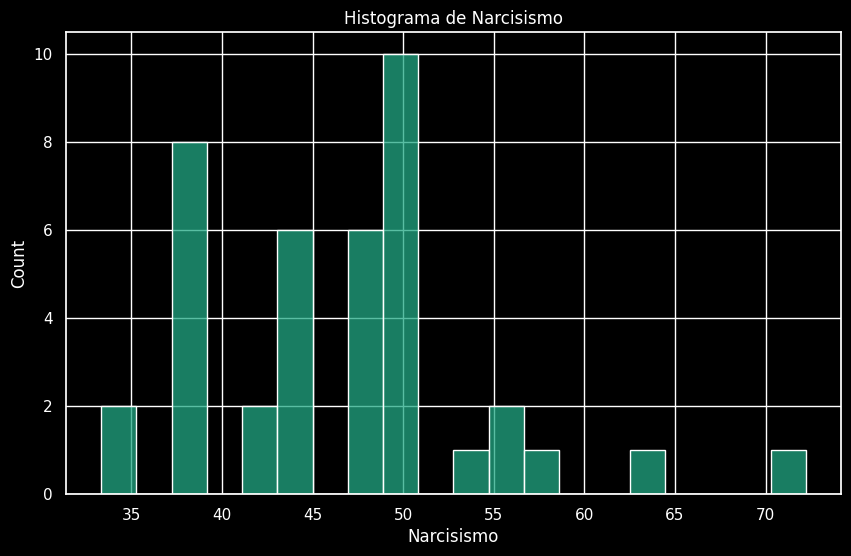

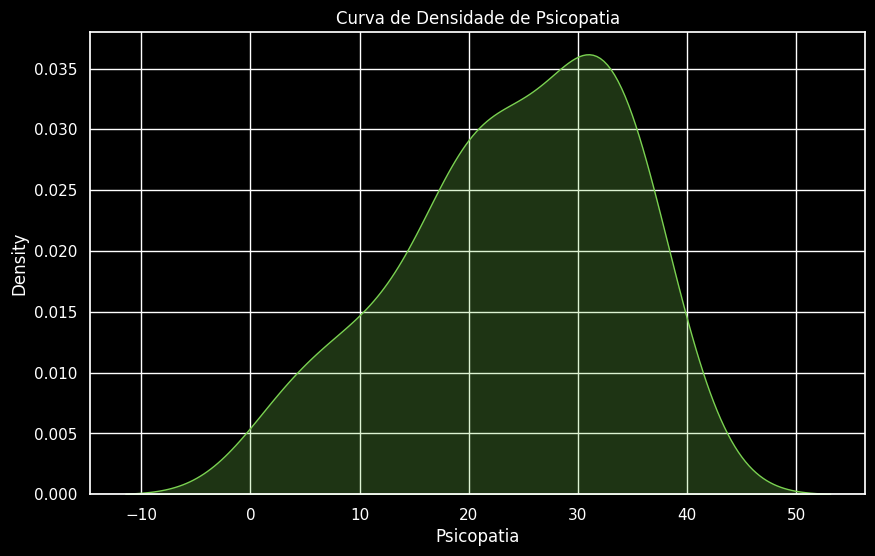

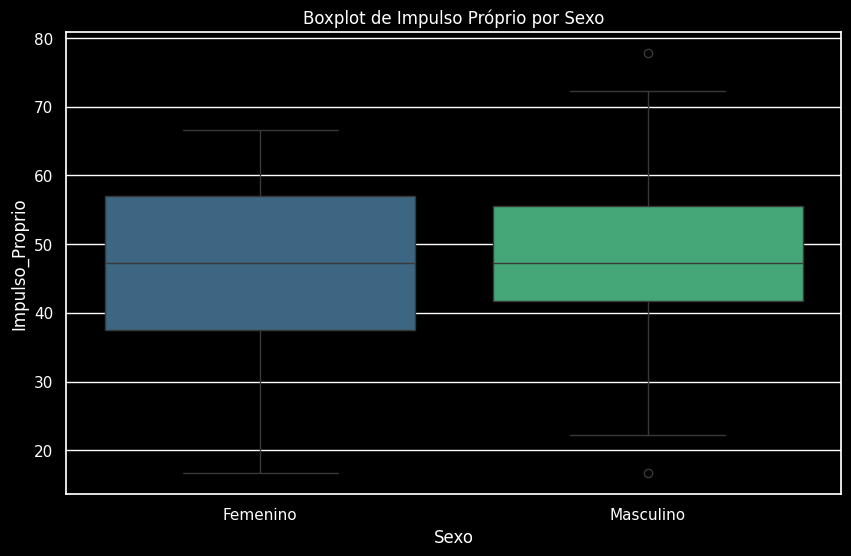

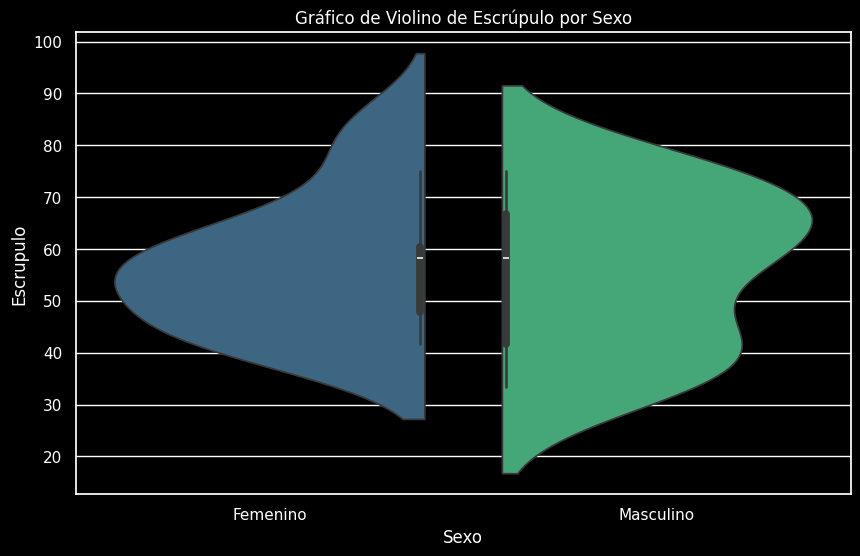

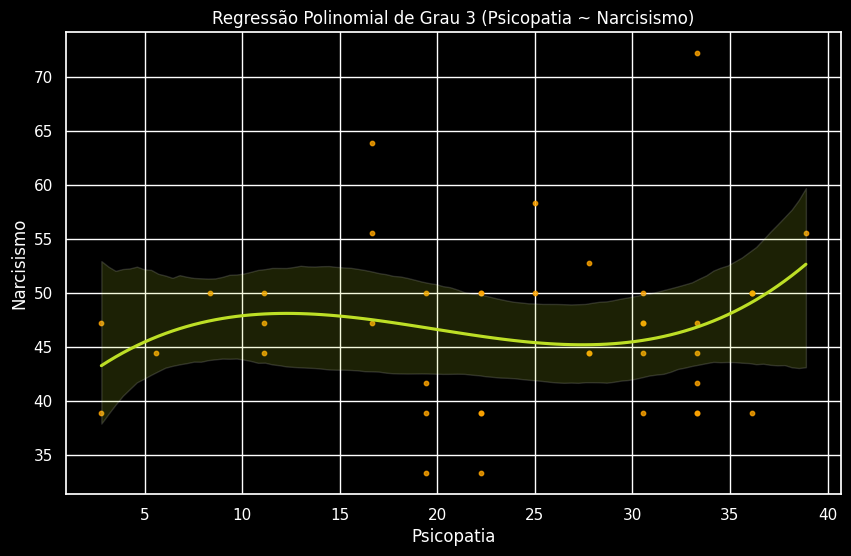

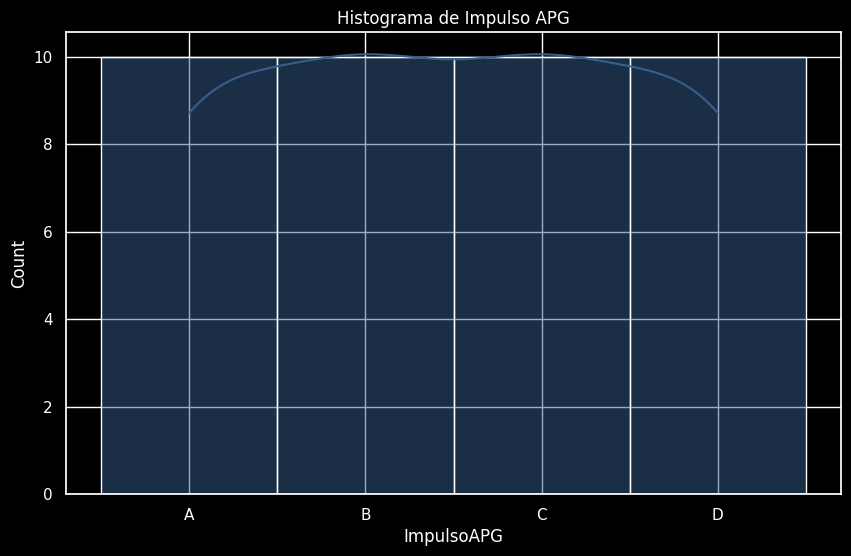

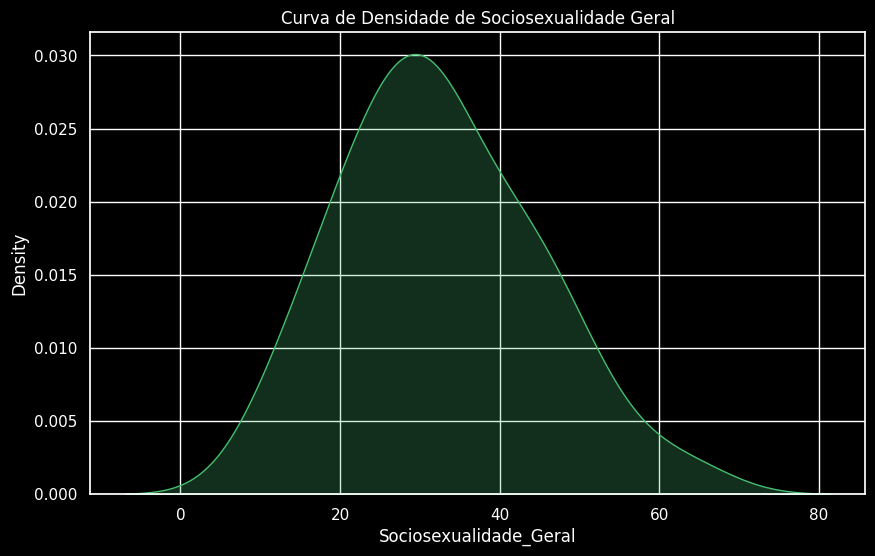

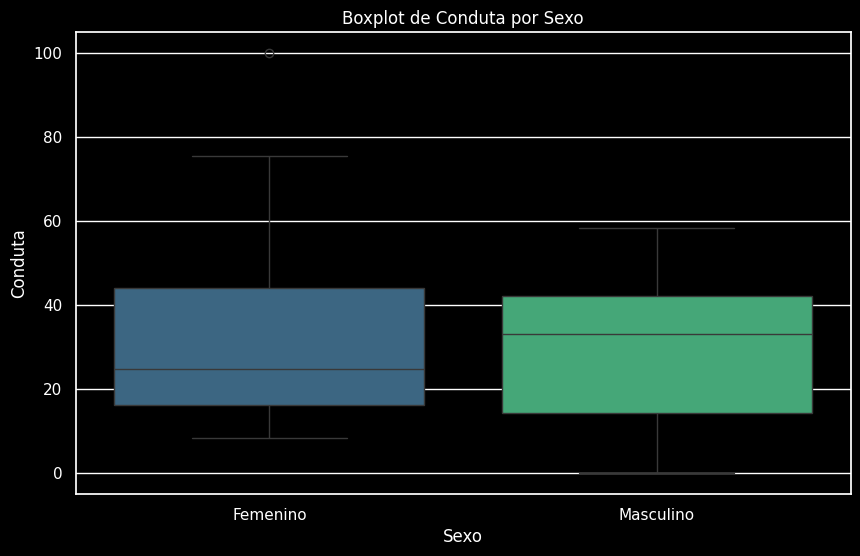

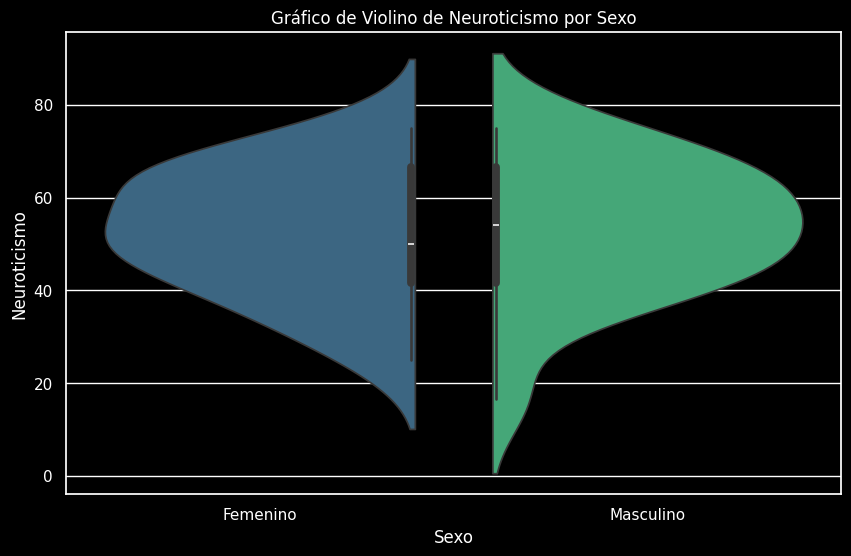

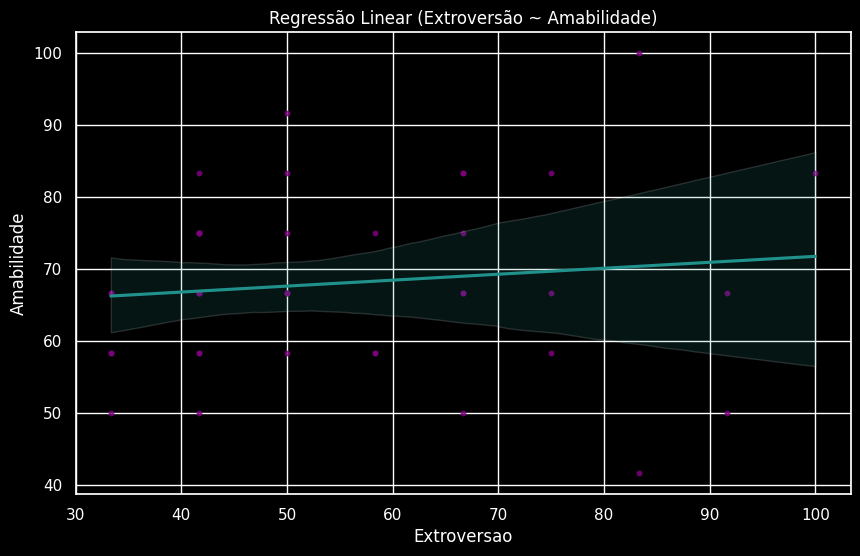

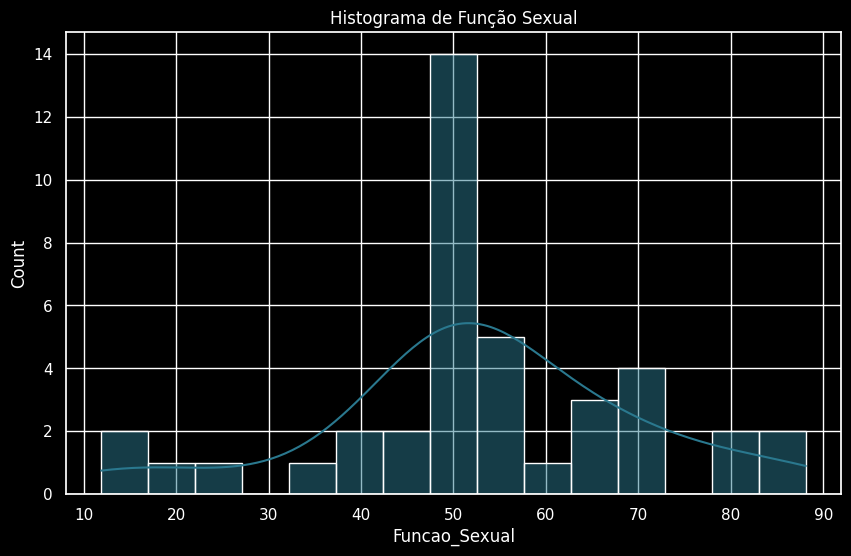

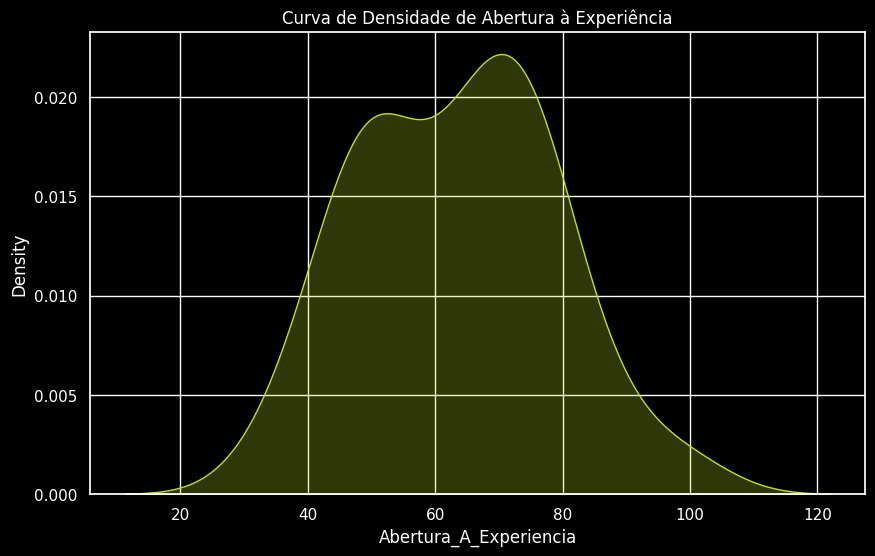

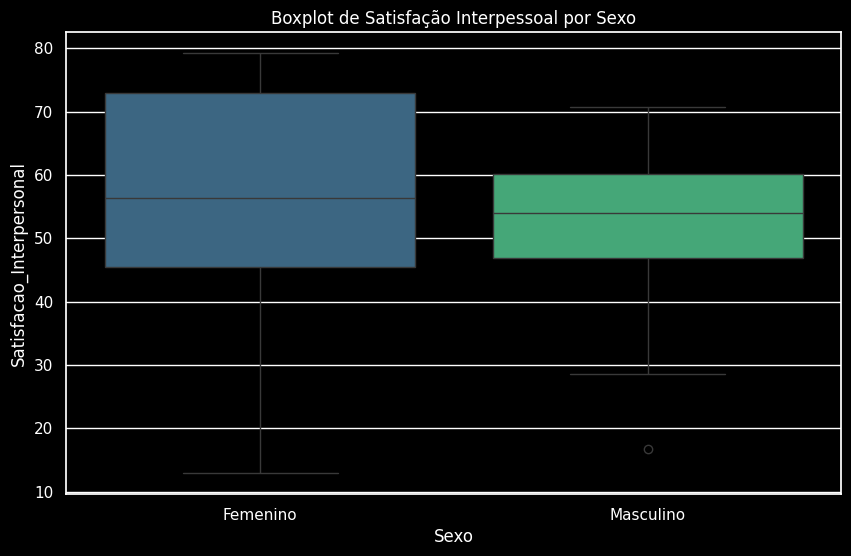

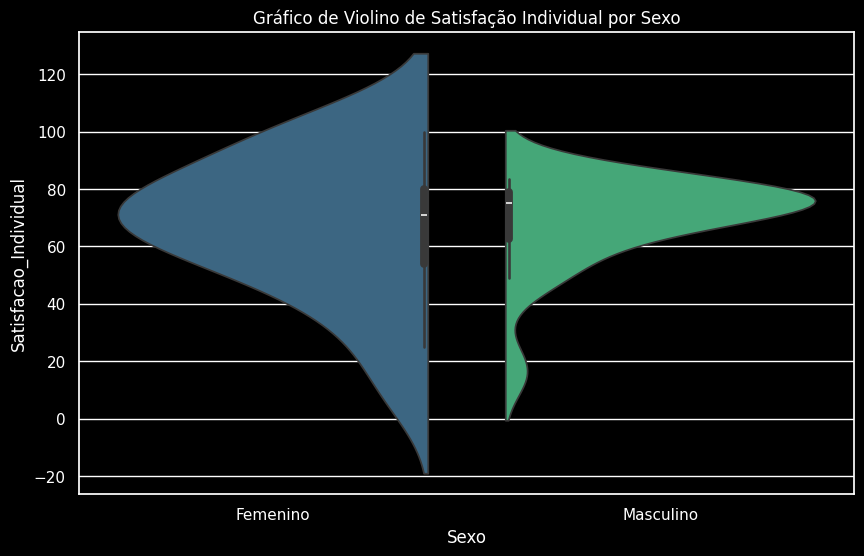

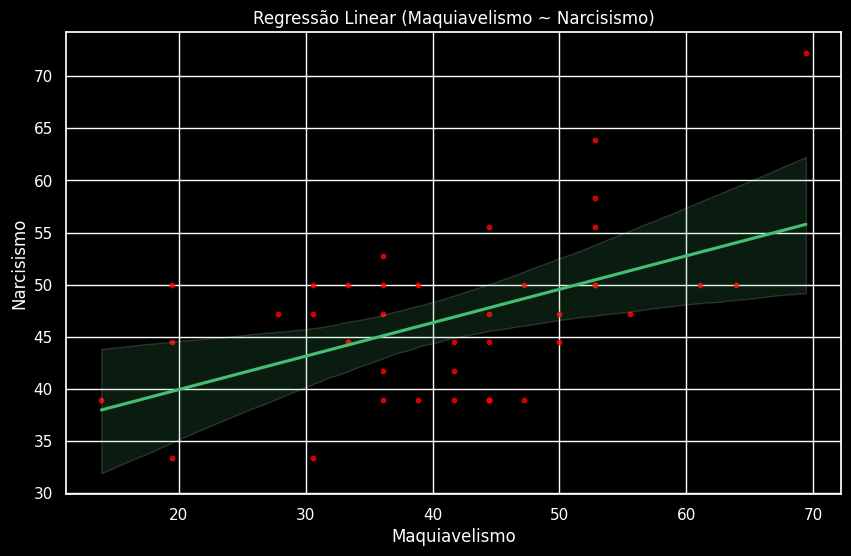

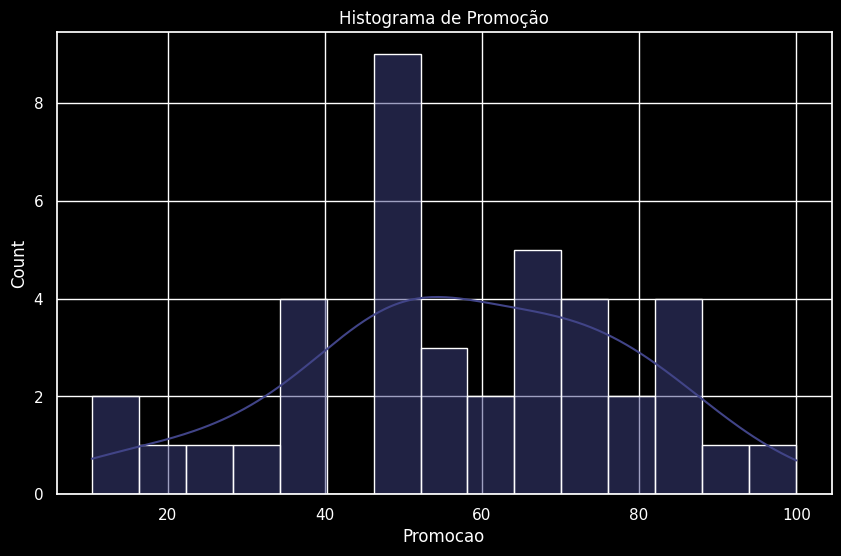

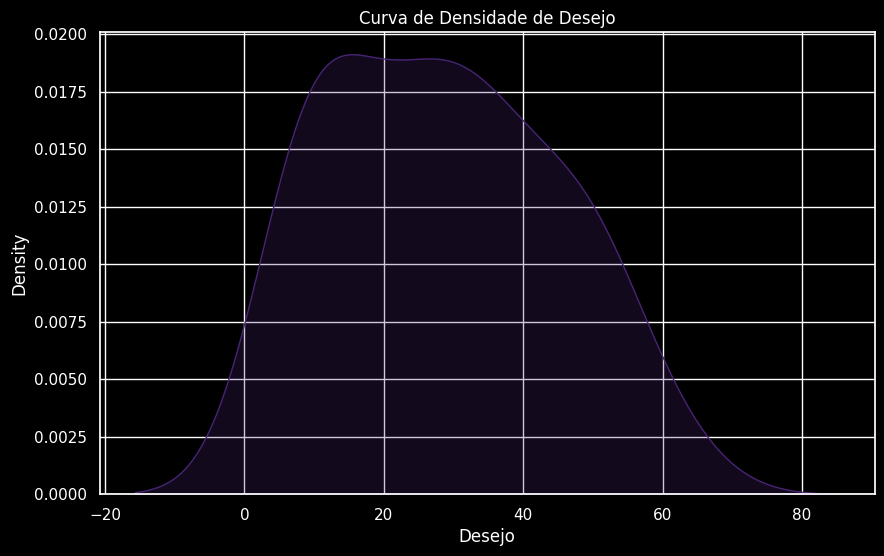

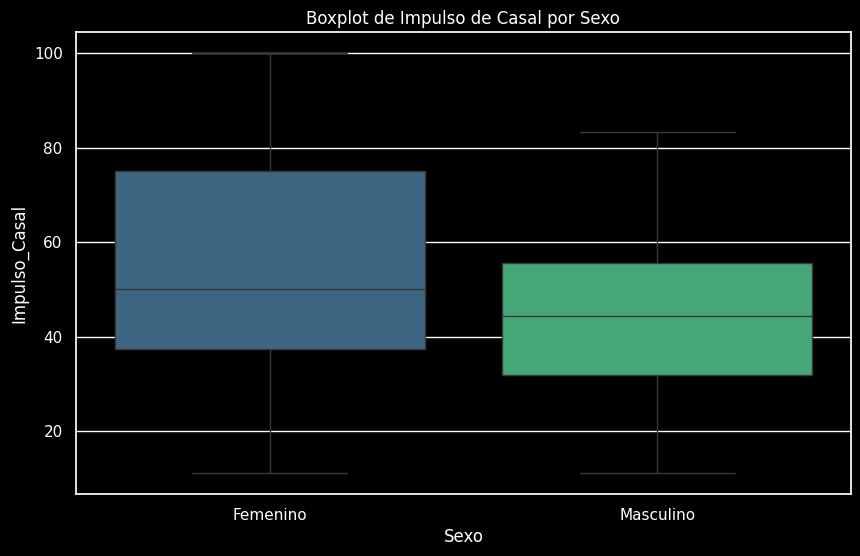

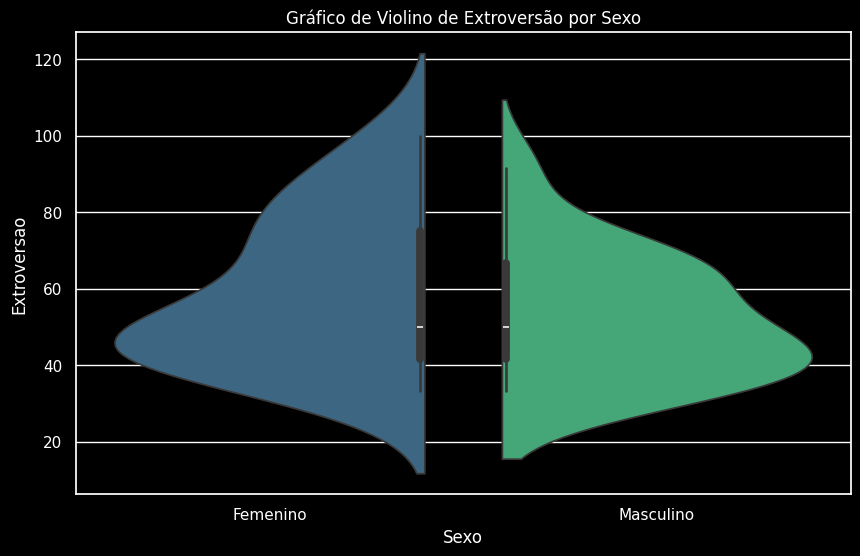

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
import csv
from google.colab import drive
import shutil
import os

# Função para carregar dados de uma URL do Google Sheets
def carregar_dados_google_sheets(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        csv_data = StringIO(response.text)
        df = pd.read_csv(csv_data)

        df.columns = df.columns.str.strip()

        for col in df.columns:
            df[col] = df[col].apply(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)
            try:
                df[col] = pd.to_numeric(df[col])
            except ValueError:
                pass

        return df
    except requests.exceptions.RequestException as e:
        print(f"Erro ao acessar a URL: {e}")
        return None
    except Exception as e:
        print(f"Erro ao carregar o CSV: {e}")
        return None

# Análise MANOVA
def realizar_manova(df, dependentes, independentes):
    try:
        df = df.dropna(subset=dependentes + independentes)

        scaler = StandardScaler()
        X = df[independentes]
        X_scaled = scaler.fit_transform(X)

        formula = f"{' + '.join(dependentes)} ~ {' + '.join(independentes)}"
        manova = MANOVA.from_formula(formula, data=df)
        return manova.mv_test()

    except Exception as e:
        print(f"Erro ao realizar MANOVA: {e}")
        return None

# Função para realizar os testes Post-Hoc
def realizar_post_hoc(df, variavel, grupo):
    try:
        df_dropna = df.dropna(subset=[variavel, grupo])

        if len(df_dropna[grupo].unique()) < 2:
            print(f"Não há grupos suficientes para realizar o teste Post-Hoc para {variavel}.")
            return None

        post_hoc = pairwise_tukeyhsd(df_dropna[variavel], df_dropna[grupo], alpha=0.05)
        return post_hoc.summary()

    except Exception as e:
        print(f"Erro ao realizar Post-Hoc: {e}")
        return None

# Função para gerar gráficos de correlação
def gerar_graficos(df):
    print("\nGerando gráficos...")

    caminho_pasta = '/content/drive/My Drive/graficos'
    if not os.path.exists(caminho_pasta):
        os.makedirs(caminho_pasta)

    sns.set(style="whitegrid")
    plt.style.use("dark_background")
    cmap = sns.color_palette("viridis", as_cmap=True)

    # 20 gráficos
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Narcisismo'], kde=False, color=cmap(0.6), bins=20)
    plt.title('Histograma de Narcisismo')
    plt.savefig(os.path.join(caminho_pasta, "histograma_narcisismo.png"))

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df['Psicopatia'], color=cmap(0.8), fill=True)
    plt.title('Curva de Densidade de Psicopatia')
    plt.savefig(os.path.join(caminho_pasta, "kde_psicopatia.png"))

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sexo', y='Impulso_Proprio', data=df, hue='Sexo', palette="viridis", legend=False)
    plt.title('Boxplot de Impulso Próprio por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "boxplot_impulso_proprio.png"))

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Sexo', y='Escrupulo', data=df, split=True, hue='Sexo', palette="viridis", legend=False)
    plt.title('Gráfico de Violino de Escrúpulo por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "violino_escrupulo.png"))

    plt.figure(figsize=(10, 6))
    df = df.dropna(subset=['Psicopatia', 'Narcisismo'])
    df['Psicopatia'] = pd.to_numeric(df['Psicopatia'], errors='coerce')
    df['Narcisismo'] = pd.to_numeric(df['Narcisismo'], errors='coerce')
    sns.regplot(x='Psicopatia', y='Narcisismo', data=df, order=3, scatter_kws={'s': 10, 'color': 'orange'}, line_kws={"color": cmap(0.9)})
    plt.title('Regressão Polinomial de Grau 3 (Psicopatia ~ Narcisismo)')
    plt.savefig(os.path.join(caminho_pasta, "regressao_polinomial.png"))

    plt.figure(figsize=(10, 6))
    sns.histplot(df['ImpulsoAPG'], kde=True, color=cmap(0.3), bins=15)
    plt.title('Histograma de Impulso APG')
    plt.savefig(os.path.join(caminho_pasta, "histograma_impulso_apg.png"))

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df['Sociosexualidade_Geral'], color=cmap(0.7), fill=True)
    plt.title('Curva de Densidade de Sociosexualidade Geral')
    plt.savefig(os.path.join(caminho_pasta, "kde_sociosexualidade.png"))

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sexo', y='Conduta', data=df, hue='Sexo', palette="viridis", legend=False)
    plt.title('Boxplot de Conduta por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "boxplot_conduta.png"))

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Sexo', y='Neuroticismo', data=df, split=True, hue='Sexo', palette="viridis", legend=False)
    plt.title('Gráfico de Violino de Neuroticismo por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "violino_neuroticismo.png"))

    plt.figure(figsize=(10, 6))
    sns.regplot(x='Extroversao', y='Amabilidade', data=df, scatter_kws={'s': 10, 'color': 'purple'}, line_kws={"color": cmap(0.5)})
    plt.title('Regressão Linear (Extroversão ~ Amabilidade)')
    plt.savefig(os.path.join(caminho_pasta, "regressao_extroversao_amabilidade.png"))

    plt.figure(figsize=(10, 6))
    sns.histplot(df['Funcao_Sexual'], kde=True, color=cmap(0.4), bins=15)
    plt.title('Histograma de Função Sexual')
    plt.savefig(os.path.join(caminho_pasta, "histograma_funcao_sexual.png"))

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df['Abertura_A_Experiencia'], color=cmap(0.9), fill=True)
    plt.title('Curva de Densidade de Abertura à Experiência')
    plt.savefig(os.path.join(caminho_pasta, "kde_abertura_experiencia.png"))

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sexo', y='Satisfacao_Interpersonal', data=df, hue='Sexo', palette="viridis", legend=False)
    plt.title('Boxplot de Satisfação Interpessoal por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "boxplot_satisfacao_interpersonal.png"))

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Sexo', y='Satisfacao_Individual', data=df, split=True, hue='Sexo', palette="viridis", legend=False)
    plt.title('Gráfico de Violino de Satisfação Individual por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "violino_satisfacao_individual.png"))

    plt.figure(figsize=(10, 6))
    sns.regplot(x='Maquiavelismo', y='Narcisismo', data=df, scatter_kws={'s': 10, 'color': 'red'}, line_kws={"color": cmap(0.7)})
    plt.title('Regressão Linear (Maquiavelismo ~ Narcisismo)')
    plt.savefig(os.path.join(caminho_pasta, "regressao_maquiavelismo_narcisismo.png"))

    plt.figure(figsize=(10, 6))
    sns.histplot(df['Promocao'], kde=True, color=cmap(0.2), bins=15)
    plt.title('Histograma de Promoção')
    plt.savefig(os.path.join(caminho_pasta, "histograma_promocao.png"))

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df['Desejo'], color=cmap(0.1), fill=True)
    plt.title('Curva de Densidade de Desejo')
    plt.savefig(os.path.join(caminho_pasta, "kde_desejo.png"))

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sexo', y='Impulso_Casal', data=df, hue='Sexo', palette="viridis", legend=False)
    plt.title('Boxplot de Impulso de Casal por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "boxplot_impulso_casal.png"))

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Sexo', y='Extroversao', data=df, split=True, hue='Sexo', palette="viridis", legend=False)
    plt.title('Gráfico de Violino de Extroversão por Sexo')
    plt.savefig(os.path.join(caminho_pasta, "violino_extroversao.png"))

    print("Gráficos salvos na pasta 'graficos' do Google Drive.\n")

# Função para gerar o sumário de correlações
def gerar_sumario_correlacoes(df):
    try:
        df_numeric = df.select_dtypes(include=[np.number])

        correlacoes = df_numeric.corr()

        print("Sumário de correlações:")
        print(correlacoes)

        return correlacoes

    except Exception as e:
        print(f"Erro ao gerar sumário de correlações: {e}")
        return None

# Função para salvar os resultados em um arquivo TXT
def salvar_resultados_txt(resultados_manova, post_hoc_tests, correlacoes, filename="sumario.txt"):
    try:
        with open(filename, mode='w', encoding='utf-8') as file:

            file.write("Resultados da MANOVA\n")
            file.write(str(resultados_manova) + "\n\n")

            for var, result in post_hoc_tests.items():
                file.write(f"Post-Hoc para {var}\n")
                file.write(str(result) + "\n\n")

            file.write("Sumário de correlações\n")
            file.write(correlacoes.to_string() + "\n")

        print(f"Resultados salvos em {filename}")
        return filename
    except Exception as e:
        print(f"Erro ao salvar o arquivo TXT: {e}")
        return None

# Função para carregar o arquivo TXT para o Google Drive usando a API nativa do Colab
def upload_to_google_drive_colab(filename):
    try:
        drive.mount('/content/drive')

        caminho_drive = f'/content/drive/My Drive/{filename}'

        if os.path.exists(filename):
            shutil.copy(filename, caminho_drive)
            print(f"Arquivo enviado com sucesso para o Google Drive: {caminho_drive}")
        else:
            print(f"Arquivo {filename} não encontrado.")

    except Exception as e:
        print(f"Erro ao enviar o arquivo para o Google Drive: {e}")

# Função principal de análise
def sumario_estatistico_analise(df):
    dependentes = ['Sociosexualidade_Geral', 'Atitude', 'Desejo', 'Promocao', 'Satisfacao_Individual']
    independentes = ['Extroversao', 'Amabilidade', 'Neuroticismo', 'Abertura_A_Experiencia', 'Narcisismo', 'Psicopatia']

    try:
        resultados_manova = realizar_manova(df, dependentes, independentes)
    except Exception as e:
        print(f"Erro na MANOVA: {e}")
        resultados_manova = None

    post_hoc_tests = {}
    for var in ['Impulso_Proprio', 'Impulso_Casal', 'Escrupulo', 'Maquiavelismo']:
        post_hoc_tests[var] = realizar_post_hoc(df, var, 'Sexo')

    gerar_graficos(df)

    correlacoes = gerar_sumario_correlacoes(df)

    filename = salvar_resultados_txt(resultados_manova, post_hoc_tests, correlacoes)

    if filename:
        upload_to_google_drive_colab(filename)

# Main: Executar a análise
if __name__ == "__main__":
    url_planilha = "https://docs.google.com/spreadsheets/d/1FUx1nRvhRRKhwYDwxUXMutXD-17lQ4I-pSZ27ERkC14/export?format=csv&gid=1161976353"
    df = carregar_dados_google_sheets(url_planilha)

    if df is not None:
        sumario_estatistico_analise(df)
    else:
        print("Erro ao carregar os dados. Verifique a URL ou o formato do arquivo.")